In [1]:
import sys
import os
import numpy as np

sys.path.append(os.path.abspath('..'))

from src.config import SolverConfig
from src.models.spacecraft import Spacecraft
from src.optimizer import Optimizer
from src.utils import cart2eq, cart2kep

from scripts.ephemerides import load_states

earth_path = "../src/horizons_results_earth_heliocentric_state_vector.txt"
mars_path = "../src/horizons_results_mars_heliocentric_state_vector.txt"

In [2]:
earth_loc, earth_dt = load_states(earth_path)
mars_loc, mars_dt = load_states(mars_path)

earth_loc = earth_loc*1e3
mars_loc = mars_loc*1e3

cfg = SolverConfig()

earth_dt[440]

Timestamp('2001-03-16 00:00:00')

In [3]:

# outer loooooop

# best from matlab
# Dep:2027-Jan-24 Arr:2027-Nov-05 TOF:285d

departures = np.linspace(400,401,1, dtype=int)
tf_days = np.linspace(700,700,1, dtype=int)

best_mf = float('inf')  # Best final mass
best_departure = None
best_tf = None
best_sol = None
best_fw_ts = None

for t0 in departures:
    print("testing departure", t0)
    for tf in tf_days:
        print("testing transfer time", tf)
        Psyche = Spacecraft()
        m0 = Psyche.m0
        r0v0 = earth_loc[t0]
        y0 = np.hstack((r0v0, m0))
        rfvf = mars_loc[t0+tf]
        yf = np.hstack((rfvf, m0))

        fw_target = cart2eq(rfvf)[0:6]
        fw_opt = Optimizer(cfg, Psyche, target_orbit=fw_target)
        fw_ts, fw_sol, fw_as, fw_es, fw_thist, fw_uhist, fw_qhist = fw_opt.simulate_forward(t0*86400, tf*86400, y0)

        # Extract final mass from solution (adjust index for your sol format)
        final_mass = fw_sol[6, -1]  # Assuming [r,v,m] format, m at index 6
        
        # Check convergence (only consider converged solutions)
        if fw_opt.check_converge(fw_sol[0:6,-1]):  # Use your converge check
            mass_consumed = m0 - final_mass
            print(f"  Converged! Δm={mass_consumed:.1f}kg mf={final_mass:.1f}kg")
            
            # Track best (highest final mass = lowest consumption)
            if final_mass > best_mf:
                best_mf = final_mass
                best_departure = t0
                best_tf = tf
                best_sol = fw_sol.copy()
                best_fw_ts = fw_ts.copy()
                print(f"  *** NEW BEST: Δm={mass_consumed:.1f}kg ***")
        else:
            print(f"  Failed convergence")

# Print/report best
print("\n=== BEST SOLUTION ===")
print(f"Departure: {best_departure} days")
print(f"TOF: {best_tf} days")
print(f"Arrival: {best_departure + best_tf} days")
print(f"Best final mass: {best_mf:.1f}kg (Δm={m0-best_mf:.1f}kg)")
print(f"Mass fraction: {best_mf/m0*100:.1f}%")

# Save best solution
np.savez('best_transfer.npz', 
         ts=best_fw_ts, sol=best_sol, 
         departure=best_departure, tof=best_tf,
         final_mass=best_mf)
print("Saved best solution to 'best_transfer.npz'")




testing departure 400
testing transfer time 700
--- SWITCHING TO PHASE 2 (PHASING) ---
65664000.0
[ 1.19106010e+11  1.92394291e+11  2.69601236e+09 -1.91601171e+04
  1.50912429e+04  7.72053511e+02  4.67448203e+03]
  Failed convergence

=== BEST SOLUTION ===
Departure: None days
TOF: None days


TypeError: unsupported operand type(s) for +: 'NoneType' and 'NoneType'

In [ ]:
mee_error = np.array(cart2eq(fw_sol[0:6,-1])) - np.array(fw_opt.true_target)
print(mee_error)
kep_error = np.array(cart2kep(fw_sol[0:6,-1])) - np.array(cart2kep(rfvf))
print(kep_error)


# def check_plane_alignment(r_sc, v_sc, r_mars, v_mars):
#     # Plane Normals
#     n_sc = np.cross(r_sc, v_sc) / np.linalg.norm(np.cross(r_sc, v_sc))
#     n_mars = np.cross(r_mars, v_mars) / np.linalg.norm(np.cross(r_mars, v_mars))
    
#     # Angular separation between planes
#     angle = np.degrees(np.arccos(np.clip(np.dot(n_sc, n_mars), -1, 1)))
    
#     # Distance of SC from Mars's orbital plane
#     dist_from_plane = np.dot(r_sc - r_mars, n_mars)
    
#     print(f"Angular Plane Error: {angle:.6f} degrees")
#     print(f"Vertical Distance from Mars Plane: {dist_from_plane/1e3:.2f} km")

# # Run this at the end of your Phase 2
# check_plane_alignment(fw_sol[0:3,-1], fw_sol[3:6,-1], rfvf[0:3], rfvf[3:6])

[ 4.89999675e+09 -7.72503321e-03 -5.14404897e-03 -1.45526574e-03
  2.57282757e-03  7.59615711e-02]
[ 4.89999675e+09 -4.62419817e-03  2.47293539e-03  1.60479862e-01
 -2.48807809e-01  1.64289518e-01]


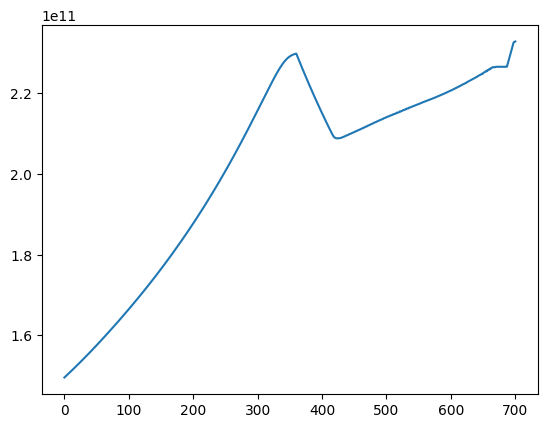

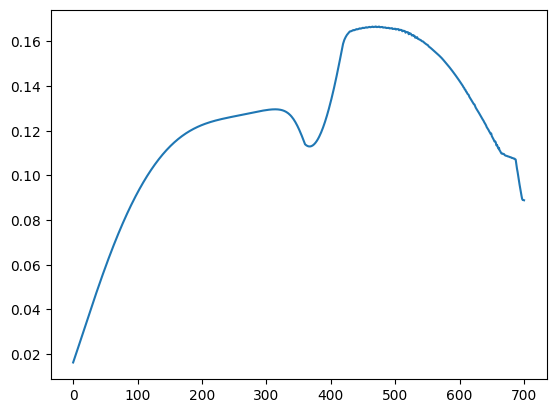

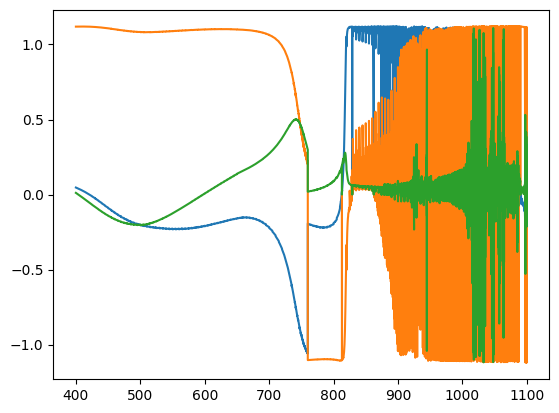

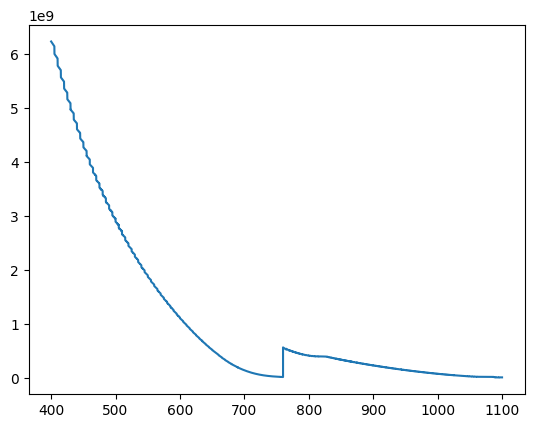

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(fw_as)
plt.show()

plt.figure()
plt.plot(fw_es)
plt.show()

plt.figure()
plt.plot(fw_thist/86400, fw_uhist)
plt.show()

plt.figure()
plt.plot(fw_thist/86400, fw_qhist)
plt.show()


In [4]:
import plotly.graph_objects as go
import numpy as np


# Convert to Gm (1e9 m)
AU_TO_GM = 1.495978707e2

# Example: pick one TOF from your loop
best_tf = tf_days[-1]  # or pick the one you want to visualize
best_t0 = t0

# Get Earth and Mars positions at t0 and t0+best_tf
earth_initial = earth_loc[best_t0,0:3]
mars_initial = mars_loc[best_t0,0:3]
mars_final= mars_loc[best_t0 + best_tf, 0:3]
earth_final= earth_loc[best_t0 + best_tf, 0:3]

mars_traj_during_flight = mars_loc[best_t0 : best_t0 + best_tf + 1, 0:3] / 1e9
earth_traj_during_flight = earth_loc[best_t0 : best_t0 + best_tf + 1, 0:3] / 1e9


# Forward trajectory (Earth -> Mars)
t_days_fw = fw_ts / 86400
r_traj_fw = fw_sol[0:3, :].T / 1e9

# Create 3D figure
fig = go.Figure()


# 1. Forward arc (Earth → Mars)
fig.add_trace(go.Scatter3d(
    x=r_traj_fw[:, 0], y=r_traj_fw[:, 1], z=r_traj_fw[:, 2],
    mode='lines',
    name='Forward Q‑law arc (Earth → Mars)',
    line=dict(width=6, color='cyan'),
    hovertemplate='<b>Time: %{text:.1f} days</b><br>X: %{x:.2f} Gm<br>Y: %{y:.2f} Gm<br>Z: %{z:.2f} Gm<extra></extra>',
    text=t_days_fw
))

# --- 2. NEW: Mars Orbit Path (The target's actual move) ---
fig.add_trace(go.Scatter3d(
    x=mars_traj_during_flight[:, 0], 
    y=mars_traj_during_flight[:, 1], 
    z=mars_traj_during_flight[:, 2],
    mode='lines',
    name='Mars Orbital Path',
    line=dict(width=4, color='red', dash='dash'), # Dashed to distinguish from spacecraft
    hovertemplate='<b>Mars Path</b><br>X: %{x:.2f} Gm<br>Y: %{y:.2f} Gm<br>Z: %{z:.2f} Gm<extra></extra>'
))
fig.add_trace(go.Scatter3d(
    x=earth_traj_during_flight[:, 0], 
    y=earth_traj_during_flight[:, 1], 
    z=earth_traj_during_flight[:, 2],
    mode='lines',
    name='Earth Orbital Path',
    line=dict(width=4, color='blue', dash='dash'), # Dashed to distinguish from spacecraft
    hovertemplate='<b>Mars Path</b><br>X: %{x:.2f} Gm<br>Y: %{y:.2f} Gm<br>Z: %{z:.2f} Gm<extra></extra>'
))

# 3. Earth initial
fig.add_trace(go.Scatter3d(
    x=[earth_initial[0]/1e9], y=[earth_initial[1]/1e9], z=[earth_initial[2]/1e9],
    mode='markers+text',
    name='Earth (Start)',
    marker=dict(size=12, color='blue'),
    text=['Earth Start'],
    textposition="middle center",
    hovertemplate='<b>Earth Initial</b><br>Position: (%{x:.2f}, %{y:.2f}, %{z:.2f}) Gm<extra></extra>'
))

switch = [ 1.19106010e+11,1.92394291e+11,2.69601236e+09]
fig.add_trace(go.Scatter3d(
    x=[switch[0]/1e9], y=[switch[1]/1e9], z=[switch[2]/1e9],
    mode='markers+text',
    name='SWITCH',
    marker=dict(size=4, color='blue'),
    text=['SWITCH'],
    textposition="middle center",
    hovertemplate='<b>Earth Initial</b><br>Position: (%{x:.2f}, %{y:.2f}, %{z:.2f}) Gm<extra></extra>'
))


# 4. Mars initial
fig.add_trace(go.Scatter3d(
    x=[mars_initial[0]/1e9], y=[mars_initial[1]/1e9], z=[mars_initial[2]/1e9],
    mode='markers+text',
    name='Mars (Start)',
    marker=dict(size=12, color='pink'),
    text=['Mars Start'],
    textposition="middle center",
    hovertemplate='<b>Mars Initial</b><br>Position: (%{x:.2f}, %{y:.2f}, %{z:.2f}) Gm<extra></extra>'
))


# 5. Mars final (target)
fig.add_trace(go.Scatter3d(
    x=[mars_final[0]/1e9], y=[mars_final[1]/1e9], z=[mars_final[2]/1e9],
    mode='markers+text',
    name='Mars (Target)',
    marker=dict(size=12, color='red'),
    text=['Mars Target'],
    textposition="middle center",
    hovertemplate='<b>Mars Target</b><br>Position: (%{x:.2f}, %{y:.2f}, %{z:.2f}) Gm<extra></extra>'
))


# 6. Earth final (target for backward arc)
fig.add_trace(go.Scatter3d(
    x=[earth_final[0]/1e9], y=[earth_final[1]/1e9], z=[earth_final[2]/1e9],
    mode='markers+text',
    name='Earth (Target)',
    marker=dict(size=12, color='lightblue'),
    text=['Earth Target'],
    textposition="middle center",
    hovertemplate='<b>Earth Target</b><br>Position: (%{x:.2f}, %{y:.2f}, %{z:.2f}) Gm<extra></extra>'
))


# 7. Sun at origin
fig.add_trace(go.Scatter3d(
    x=[0], y=[0], z=[0],
    mode='markers',
    name='Sun',
    marker=dict(size=15, color='yellow', symbol='circle', line=dict(color='orange', width=2))
))


# 8. Auxiliary: Earth initial state point (r0v0) and Mars final state point 